In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def least_square_fitting(X, Y,plot):
    # TABLE DATA
    Σx2 = 0
    Σy = 0
    Σxy = 0
    Σx = 0
    count = 0
    Σxylist = []
    Σx2list = []
    Slno = []

    for i in range(len(X)):
        Σx2 += X[i]**2
        Σx2list.append(round(X[i]**2,4))
        Σy += Y[i]
        Σxy += X[i]*Y[i]
        Σxylist.append(round(X[i]*Y[i],4))
        Σx += X[i]
        count += 1
        Slno.append(count)

    # Finding slope and intercept
    fit = np.polyfit(X,Y,1)
    A = fit[0]
    B = fit[1]
    def f(x):
      return A*x + B
    # Error analysis
    error_sum = 0
    for i in range(len(X)):
        error_sum += (Y[i] - f(X[i]))**2
    error_y = (error_sum/ (len(X) - 2))**0.5
    delta = len(X)*Σx2 - Σx**2
    error_slope = error_y * (len(X)/delta)**0.5
    error_intercept = error_y * (Σx2/delta)**0.5

    if plot==True:
        #GRAPH PLOT
        # plt.xlabel(X_axis)
        # plt.ylabel(Y_axis)
        # plt.title(X_axis + " vs " + Y_axis + 'at probe current='+str(Ip)+' mA')
        plt.grid()
        plt.scatter(X,Y,s=20,c='orange')
        fit = np.polyfit(X,Y,1)
        x_fit = np.linspace(min(X),max(X),1000)
        y_fit = fit[1]+fit[0]*x_fit
        plt.plot(x_fit,y_fit,'--',color = 'r', label = f'Least-square fit line : y = ({round(A,3)}±{round(error_slope,3)})x + ({round(B,3)}±{round(error_intercept,3)})')

        
    if plot==False:
        return ['Slope = ', A, 'Intercept = ', B, 'Error in slope = ', error_slope, 'Error in intercept = ', error_intercept]


In [ ]:

# Parameters
Cf = 5.28 # nF (10.45 + 10.6)
Rf = 9.78 # kohm 9.43kohm
w = 2*np.pi*5 # kHz 

# Data for dark
V_dc = [0,0.1,0.2,0.3,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5] # in V
V_dut = [0,-0.1005,-0.2237,-0.3556,-0.5122,-0.606,-0.757,-0.854,-0.927,-1.037,-1.136,-1.24,-1.331,-1.424,-1.588] # in V
V_o = [0.2,0.196,0.191,0.187,0.182,0.179,0.175,0.172,0.17,0.168,0.166,0.163,0.161,0.159,0.156] # in V

# Data for light
V_dcL = [0,0.1,0.2,0.3,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5] # in V
V_dutL = [0.0002,-0.1343,-0.2280,-0.3528,-0.493,-0.626,-0.776,-0.876,-0.965,-1.075,-1.135,-1.211,-1.346,-1.439,-1.590] # in V
V_oL = [0.782,0.780,0.780,0.779,0.778,0.778,0.777,0.776,0.776,0.775,0.775,0.775,0.775,0.774,0.773] # in V


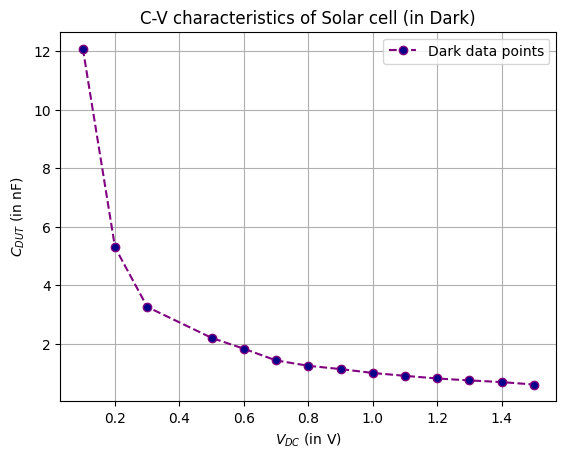

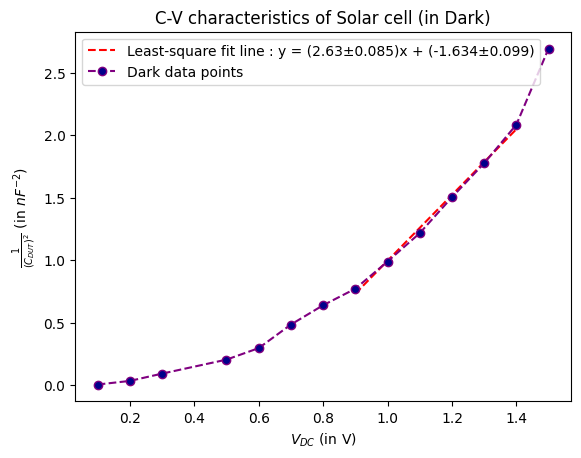

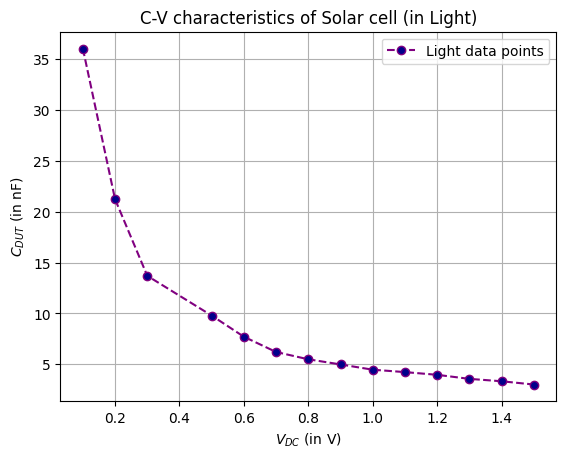

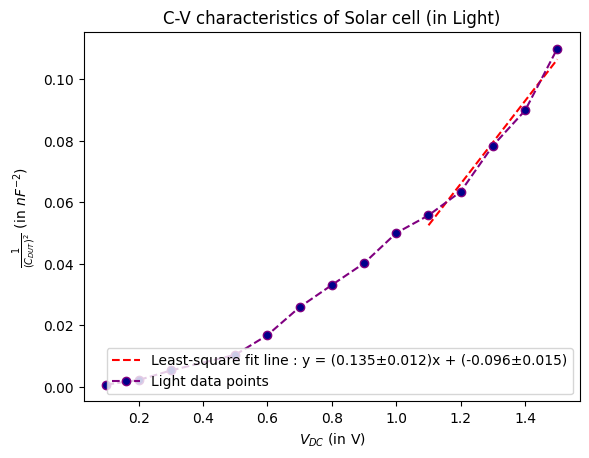

In [9]:
# DARK
Cdut = [] # nF
for i in range(1,len(V_o)):
    root = np.sqrt(1+(1/(w*Rf*Cf*1e-3)**2))
    Cdut.append((V_o[i]*root*Cf)/abs(V_dut[i]))
# print(Cdut)
Y = [1/c**2 for c in Cdut]  # 1/(nF)**2
X = V_dc


# Plots
plt.plot(V_dc[1:],Cdut,marker='o',mfc='darkblue',color='purple',linestyle='--',label='Dark data points')
plt.ylabel(r'$C_{DUT}$ (in nF)')
plt.xlabel(r'$V_{DC}$ (in V)')
plt.title('C-V characteristics of Solar cell (in Dark)')
plt.legend()
plt.grid()
plt.show()

fitxd = X[8:14]
fityd = Y[7:13]
least_square_fitting(fitxd,fityd,True)
plt.plot(X[1:],Y,marker='o',mfc='darkblue',color='purple',linestyle='--',label='Dark data points')
plt.ylabel(r'$\frac{1}{(C_{DUT})^2}$ (in $nF^{-2}$)')
plt.xlabel(r'$V_{DC}$ (in V)')
plt.title('C-V characteristics of Solar cell (in Dark)')
plt.legend()
plt.grid()
plt.show()


# LIGHT
CdutL = [] # nF
for i in range(1,len(V_o)):
    root = np.sqrt(1+(1/(w*Rf*Cf*1e-3)**2))
    CdutL.append((V_oL[i]*root*Cf)/abs(V_dutL[i]))

YL = [1/c**2 for c in CdutL]  # 1/(nF)**2
XL = V_dcL

# Plots
plt.plot(V_dcL[1:],CdutL,marker='o',mfc='darkblue',color='purple',linestyle='--',label='Light data points')
plt.ylabel(r'$C_{DUT}$ (in nF)')
plt.xlabel(r'$V_{DC}$ (in V)')
plt.title('C-V characteristics of Solar cell (in Light)')
plt.legend()
plt.grid()
plt.show()

fitxL = XL[10:15]
fityL = YL[9:14]
least_square_fitting(fitxL,fityL,True)
plt.plot(XL[1:],YL,marker='o',mfc='darkblue',color='purple',linestyle='--',label='Light data points')
plt.ylabel(r'$\frac{1}{(C_{DUT})^2}$ (in $nF^{-2}$)')
plt.xlabel(r'$V_{DC}$ (in V)')
plt.title('C-V characteristics of Solar cell (in Light)')
plt.legend()
plt.grid()
plt.show()
